In [2]:
import os
import sys
import time
import math
import json
import shutil
import platform
import datetime
from pathlib import Path

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

# --- Chargement du .env (pour PROJECT_ROOT / OUTPUT_PATH) ---
try:
    from dotenv import load_dotenv
    env_path = Path.cwd().parent / "src" / ".env"
    print(f"Chargement .env : {env_path} - existe : {env_path.exists()}")
    load_dotenv(dotenv_path=env_path, override=True)
except ImportError:
    print("WARN - python-dotenv non installe. Lance : pip install python-dotenv")

# --- Chemins ---
SCRIPT_DIR   = Path().resolve()
PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT", str(SCRIPT_DIR.parent)))
OUTPUT_DIR   = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "DejaVu Sans"

print(f"OK - Python       : {sys.version.split()[0]}")
print(f"OK - NumPy        : {np.__version__}")
print(f"OK - Pandas       : {pd.__version__}")
print(f"OK - PROJECT_ROOT : {PROJECT_ROOT}")
print(f"OK - OUTPUT_DIR   : {OUTPUT_DIR}")


Chargement .env : c:\Users\bouac\Desktop\Projet Spark streming\ChestX6-Streaming\src\.env - existe : False
OK - Python       : 3.14.4
OK - NumPy        : 2.4.4
OK - Pandas       : 3.0.2
OK - PROJECT_ROOT : C:\Users\bouac\Desktop\Projet Spark streming\ChestX6-Streaming
OK - OUTPUT_DIR   : C:\Users\bouac\Desktop\Projet Spark streming\ChestX6-Streaming\output


In [3]:
# --- Donnees ---
PARQUET_PATH = Path(os.environ.get("OUTPUT_PATH", str(PROJECT_ROOT / "results" / "train.parquet")))

# --- Modele : RandomForest multi-classe ---
N_ESTIMATORS = 100                # nombre d'arbres (moins = plus rapide)
MAX_DEPTH    = 10                 # profondeur max (moins = plus rapide)
SEED         = 42
N_JOBS       = -1                 # tous les coeurs CPU

# --- Sorties ---
MODEL_PATH  = str(OUTPUT_DIR / "chestx6_model.joblib")
LABELS_PATH = str(OUTPUT_DIR / "chestx6_labels.joblib")
JSON_PATH   = str(OUTPUT_DIR / "resultats_test.json")

print("OK - Configuration chargee")
print(f"  Parquet : {PARQUET_PATH}")
print(f"  RandomForest : {N_ESTIMATORS} arbres, depth={MAX_DEPTH}")

OK - Configuration chargee
  Parquet : C:\Users\bouac\Desktop\Projet Spark streming\ChestX6-Streaming\results\train.parquet
  RandomForest : 100 arbres, depth=10


---
## 3. Lecture du parquet

Le consumer Scala a déjà écrit les features (224×224×3 = 150 528 floats normalisés) dans
`results/train.parquet`. On charge avec pandas — pas de retraitement.

In [4]:
if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Parquet introuvable : {PARQUET_PATH}")

print(f"Lecture : {PARQUET_PATH}")
df_all = pd.read_parquet(PARQUET_PATH)
print(f"OK - {len(df_all)} lignes chargees")
print(f"Colonnes : {list(df_all.columns)}")

FEATURE_DIM = int(np.asarray(df_all['features'].iloc[0]).shape[0])
print(f"OK - {FEATURE_DIM} features par image")
print()
print("Distribution des classes dans le parquet :")
print(df_all['label'].value_counts().to_string())

Lecture : C:\Users\bouac\Desktop\Projet Spark streming\ChestX6-Streaming\results\train.parquet
OK - 14551 lignes chargees
Colonnes : ['path', 'split', 'label', 'features']
OK - 150528 features par image

Distribution des classes dans le parquet :
label
Normal                 2671
Tuberculosis           2600
Covid-19               2417
Pneumonia-Viral        2413
Pneumonia-Bacterial    2400
Emphysema              2050


---
## 4. Encodage des labels + split train/test 80/20

`LabelEncoder` convertit les noms de classes (`Covid-19`, `Normal`, …) en indices 0-3.
Le split est stratifié par classe pour garder la même proportion dans train et test.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encodage : "Covid-19"/"Normal"/... -> 0/1/2/3
label_encoder = LabelEncoder()
df_all['y'] = label_encoder.fit_transform(df_all['label'])
CLASS_LABELS = label_encoder.classes_.tolist()
print(f"Classes : {CLASS_LABELS}")

# Matrice X (n_samples, 150528)
X = np.vstack(df_all['features'].values).astype(np.float32)
y = df_all['y'].values

# Split stratifie 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"OK - Train : {len(y_train)} | Test : {len(y_test)}")
print(f"    X_train shape : {X_train.shape}")

Classes : ['Covid-19', 'Emphysema', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'Tuberculosis']
OK - Train : 11640 | Test : 2911
    X_train shape : (11640, 150528)


---
## 5. Distribution des classes (train)

Distribution :
label
Covid-19               2417
Emphysema              2050
Normal                 2671
Pneumonia-Bacterial    2400
Pneumonia-Viral        2413
Tuberculosis           2600


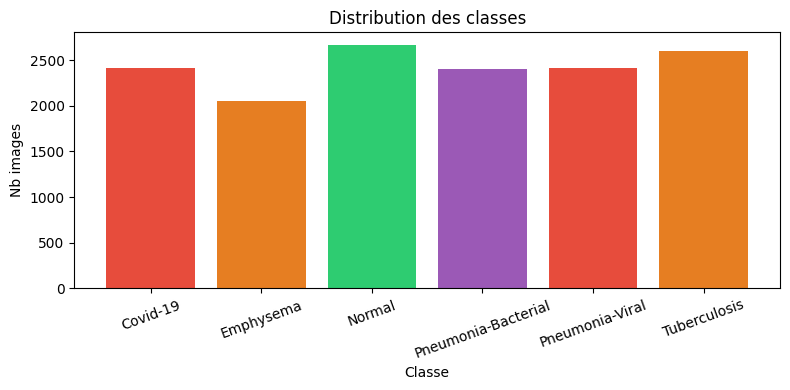

In [6]:
dist = df_all['label'].value_counts().sort_index()
print("Distribution :")
print(dist.to_string())

plt.figure(figsize=(8, 4))
plt.bar(dist.index, dist.values, color=['#e74c3c', '#e67e22', '#2ecc71', '#9b59b6'])
plt.title("Distribution des classes")
plt.xlabel("Classe"); plt.ylabel("Nb images")
plt.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "distribution_classes.png"), dpi=100, bbox_inches='tight')
plt.show()

---
## 6. Pipeline

`StandardScaler` centre/réduit chaque feature, puis `RandomForestClassifier` prédit
directement parmi les 4 classes.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("rf",     RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        n_jobs=N_JOBS,
        random_state=SEED,
    ))
])

print(f"OK - Pipeline : StandardScaler -> RandomForest({N_ESTIMATORS} arbres, depth={MAX_DEPTH})")

OK - Pipeline : StandardScaler -> RandomForest(100 arbres, depth=10)


## 7. Entraînement

In [8]:
print("Entrainement en cours...")
t0 = time.time()
model.fit(X_train, y_train)
elapsed = time.time() - t0
print(f"OK - Modele entraine en {elapsed:.1f}s ({elapsed/60:.1f} min)")

Entrainement en cours...
OK - Modele entraine en 106.9s (1.8 min)


## 8. Évaluation sur le test set

In [9]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report)

y_pred = model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print("="*45)
print("  RESULTATS TEST")
print("="*45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Rappel    : {rec:.4f}")
print("="*45)
print()
print(classification_report(y_test, y_pred, target_names=CLASS_LABELS, zero_division=0))

  RESULTATS TEST
  Accuracy  : 0.7987  (79.87%)
  F1-Score  : 0.7973
  Precision : 0.7986
  Rappel    : 0.7987

                     precision    recall  f1-score   support

           Covid-19       0.75      0.80      0.77       484
          Emphysema       0.78      0.71      0.74       410
             Normal       0.88      0.89      0.88       534
Pneumonia-Bacterial       0.69      0.77      0.73       480
    Pneumonia-Viral       0.72      0.63      0.67       483
       Tuberculosis       0.95      0.97      0.96       520

           accuracy                           0.80      2911
          macro avg       0.79      0.79      0.79      2911
       weighted avg       0.80      0.80      0.80      2911



## 9. Matrice de confusion

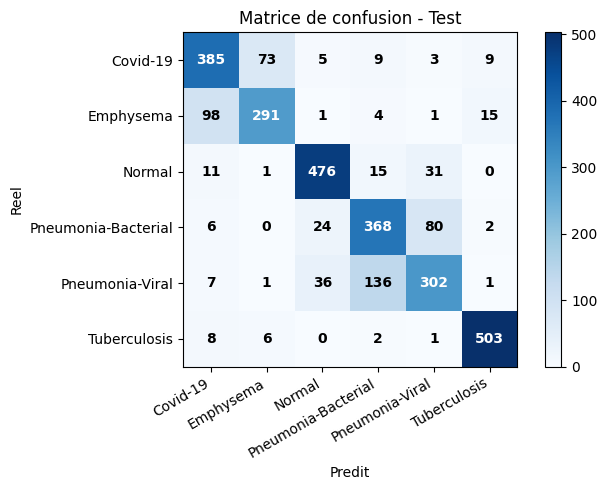

In [10]:
n  = len(CLASS_LABELS)
cm = confusion_matrix(y_test, y_pred, labels=list(range(n)))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(CLASS_LABELS, rotation=30, ha='right')
ax.set_yticklabels(CLASS_LABELS)
ax.set_xlabel('Predit'); ax.set_ylabel('Reel')
ax.set_title('Matrice de confusion - Test')
threshold = cm.max() / 2 if cm.max() > 0 else 1
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontweight='bold',
                color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "confusion_matrix_test.png"), dpi=100, bbox_inches='tight')
plt.show()

## 10. Sauvegarde du modèle + JSON

In [ ]:
import joblib

# --- 1. joblib (pour rechargement Python) ---
joblib.dump(model, MODEL_PATH, compress=3)
joblib.dump(label_encoder, LABELS_PATH)
print(f"OK - Modele joblib : {MODEL_PATH}")
print(f"OK - Labels joblib : {LABELS_PATH}")

# --- 2. ONNX (pour rechargement Scala dans le consumer) ---
try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType

    onnx_path = str(OUTPUT_DIR / "chestx6_model.onnx")
    initial_types = [("float_input", FloatTensorType([None, FEATURE_DIM]))]
    onnx_model = convert_sklearn(
    model,
    initial_types=initial_types,
    target_opset=15,
    options={id(model): {'zipmap': False}},   
)
    with open(onnx_path, "wb") as f:
        f.write(onnx_model.SerializeToString())
    print(f"OK - Modele ONNX  : {onnx_path}")
except ImportError:
    print("WARN - skl2onnx pas installe. Lance : pip install skl2onnx")

# Liste des classes en JSON (pour que Scala mappe idx -> nom)
labels_json_path = str(OUTPUT_DIR / "chestx6_labels.json")
with open(labels_json_path, "w", encoding="utf-8") as f:
    json.dump(CLASS_LABELS, f, ensure_ascii=False)
print(f"OK - Labels JSON  : {labels_json_path}")

# --- 3. JSON des metriques (pour Streamlit) ---
resultats = {
    "meta": {
        "modele"         : "RandomForest multi-classe",
        "classes"        : CLASS_LABELS,
        "features_dim"   : FEATURE_DIM,
        "n_train"        : int(len(y_train)),
        "n_test"         : int(len(y_test)),
        "date_generation": datetime.datetime.now().isoformat(timespec='seconds'),
    },
    "metriques_test": {
        "accuracy":  round(acc,  4),
        "f1":        round(f1,   4),
        "precision": round(prec, 4),
        "recall":    round(rec,  4),
    },
    "matrice_confusion": {
        "labels": CLASS_LABELS,
        "test":   cm.tolist(),
    },
}
with open(JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(resultats, f, indent=2, ensure_ascii=False)
print(f"OK - JSON metriques : {JSON_PATH}")

OK - Modele joblib : C:\Users\bouac\Desktop\Projet Spark streming\ChestX6-Streaming\output\chestx6_model.joblib
OK - Labels joblib : C:\Users\bouac\Desktop\Projet Spark streming\ChestX6-Streaming\output\chestx6_labels.joblib
OK - Modele ONNX  : C:\Users\bouac\Desktop\Projet Spark streming\ChestX6-Streaming\output\chestx6_model.onnx
OK - Labels JSON  : C:\Users\bouac\Desktop\Projet Spark streming\ChestX6-Streaming\output\chestx6_labels.json
OK - JSON metriques : C:\Users\bouac\Desktop\Projet Spark streming\ChestX6-Streaming\output\resultats_test.json


---
## 11. Résumé

In [12]:
print("=" * 60)
print("  RESUME")
print("=" * 60)
print(f"  Modele        : RandomForest ({N_ESTIMATORS} arbres, depth={MAX_DEPTH})")
print(f"  Features/img  : {FEATURE_DIM}")
print(f"  Classes       : {', '.join(CLASS_LABELS)}")
print(f"  Train / Test  : {len(y_train)} / {len(y_test)}")
print(f"  Entrainement  : {elapsed:.1f}s ({elapsed/60:.1f} min)")
print()
print(f"  TEST  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  TEST  F1-Score : {f1:.4f}")
print()
print("  Fichiers generes dans output/ :")
for f in ["chestx6_model.joblib", "chestx6_labels.joblib",
          "resultats_test.json",
          "distribution_classes.png", "confusion_matrix_test.png"]:
    print(f"    - {f}")
print("=" * 60)

  RESUME
  Modele        : RandomForest (100 arbres, depth=10)
  Features/img  : 150528
  Classes       : Covid-19, Emphysema, Normal, Pneumonia-Bacterial, Pneumonia-Viral, Tuberculosis
  Train / Test  : 11640 / 2911
  Entrainement  : 106.9s (1.8 min)

  TEST  Accuracy : 0.7987  (79.87%)
  TEST  F1-Score : 0.7973

  Fichiers generes dans output/ :
    - chestx6_model.joblib
    - chestx6_labels.joblib
    - resultats_test.json
    - distribution_classes.png
    - confusion_matrix_test.png


In [13]:
print("OK - Notebook termine")

OK - Notebook termine
